In [4]:
%reload_ext autoreload
%autoreload 2

import c2qa
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.converters import circuit_to_gate
from qiskit.circuit.library import UnitaryGate
from custom_gates import jch_sim

In [ ]:
cutoff = 2**2
qmr = c2qa.QumodeRegister(num_qumodes=3, num_qubits_per_qumode=int(np.ceil(np.log2(cutoff))))
qbr = QuantumRegister(3)
circuit = c2qa.CVCircuit(qmr,qbr)
circuit.cv_initialize(2, qmr[0])

In [6]:
U1 = jch_sim.createCircuit(3,3,cutoff,1,2.0 * 2 * np.pi,3.0 * 2 * np.pi  ,0.5 * 2 * np.pi,0.1 )

In [7]:
tarray = np.arange(0, 50*0.1, 0.1)
occupancy_list = np.zeros((len(tarray),3))
i = 0
for tau in tarray:
    print('Timestep ' + str(int(i+1)) + '/' + str(len(tarray)))
    circuit.append(U1,qmr[:]+qbr[:])
    state, result, _ = c2qa.util.simulate(circuit)
    occupancy, _ = c2qa.util.stateread(state, 3,3,4, verbose=False,little_endian=False)
    occupancy_list[i,:]=np.array(occupancy[0])
    i = i+1

Timestep 1/50
Timestep 2/50
Timestep 3/50
Timestep 4/50
Timestep 5/50
Timestep 6/50
Timestep 7/50
Timestep 8/50
Timestep 9/50
Timestep 10/50
Timestep 11/50
Timestep 12/50
Timestep 13/50
Timestep 14/50
Timestep 15/50
Timestep 16/50
Timestep 17/50
Timestep 18/50
Timestep 19/50
Timestep 20/50
Timestep 21/50
Timestep 22/50
Timestep 23/50
Timestep 24/50
Timestep 25/50
Timestep 26/50
Timestep 27/50
Timestep 28/50
Timestep 29/50
Timestep 30/50
Timestep 31/50
Timestep 32/50
Timestep 33/50
Timestep 34/50
Timestep 35/50
Timestep 36/50
Timestep 37/50
Timestep 38/50
Timestep 39/50
Timestep 40/50
Timestep 41/50
Timestep 42/50
Timestep 43/50
Timestep 44/50
Timestep 45/50
Timestep 46/50
Timestep 47/50
Timestep 48/50
Timestep 49/50
Timestep 50/50


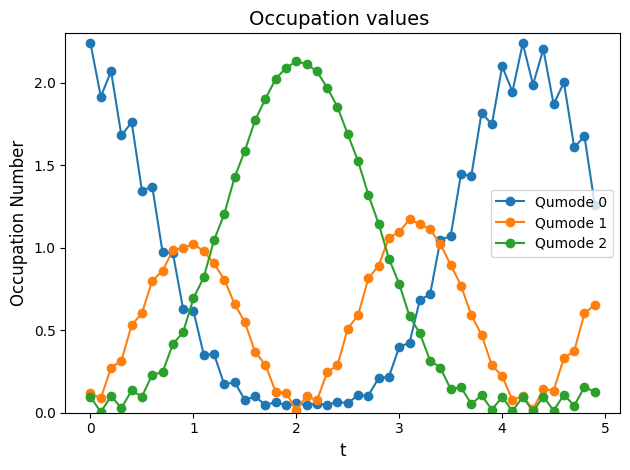

In [9]:
data1 = occupancy_list
time_steps = tarray

plt.plot(time_steps, data1[:, 0], label='Qumode 0', marker='o')  # Qumode 0
plt.plot(time_steps, data1[:, 1], label='Qumode 1', marker='o')  # Qumode 1
plt.plot(time_steps, data1[:, 2], label='Qumode 2', marker='o')  # Qumode 2
# plt.plot(time_steps, data1[:, 3], label='Qumode 3', marker='o')  # Qumode 3

plt.title('Occupation values ', fontsize=14)
plt.xlabel('t', fontsize=12)
plt.ylabel('Occupation Number', fontsize=12)
plt.ylim(0,2.3)

plt.legend()


plt.tight_layout()
plt.show()